In [16]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 

In [17]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\ai_writing_detection_dataset.csv")
df = data.copy()
df.head()

,Student_ID,Submission_Type,Academic_Level,Primary_Language,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Font_Family,Submission_Hour,Is_AI_Assisted
0,16959e76,Lab_Report,Postgraduate,Native,1552,16.90,8,0.62,0.11,11.85,129.05,16.0,24.70,3.02,0.0,0.08,2.01,Arial,18,0
1,0a304e7f,Research_Paper,Undergraduate,Native,950,16.71,5,0.47,0.31,10.34,236.60,23.0,38.84,1.71,15.0,0.07,1.72,Helvetica,15,0
2,6e629f9f,Essay,Undergraduate,Non_Native,1103,22.10,1,0.76,0.38,14.35,4.72,4.0,0.00,0.41,0.0,0.08,2.35,Arial,17,1
3,16334d32,Essay,Postgraduate,Native,1189,20.00,7,0.61,0.26,10.93,NaN,24.0,41.92,3.06,5.0,0.05,1.68,Times New Roman,5,0
4,54d8e254,Essay,Undergraduate,Native,1035,22.67,2,0.80,0.33,15.30,16.82,2.0,0.00,2.78,1.0,0.09,2.90,Helvetica,8,1


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               10200 non-null  str    
 1   Submission_Type          10200 non-null  str    
 2   Academic_Level           10200 non-null  str    
 3   Primary_Language         10200 non-null  str    
 4   Word_Count               10200 non-null  int64  
 5   Average_Sentence_Length  10200 non-null  float64
 6   Grammar_Errors           10200 non-null  int64  
 7   Vocabulary_Richness      10200 non-null  float64
 8   Passive_Voice_Ratio      10200 non-null  float64
 9   Reading_Level            10200 non-null  float64
 10  Editing_Time             9311 non-null   float64
 11  Revision_Count           8687 non-null   float64
 12  Typing_Speed             9197 non-null   float64
 13  Plagiarism_Score         9387 non-null   float64
 14  Citation_Count           9207 non

In [19]:
df.describe()

,Word_Count,Average_Sentence_Length,Grammar_Errors,Vocabulary_Richness,Passive_Voice_Ratio,Reading_Level,Editing_Time,Revision_Count,Typing_Speed,Plagiarism_Score,Citation_Count,Punctuation_Density,Sentence_Complexity,Submission_Hour,Is_AI_Assisted
count,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000,9311.000000,8687.000000,9197.000000,9387.000000,9207.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,1201.668627,16.941588,7.336275,0.622392,0.204774,11.479884,161.758765,21.543571,164.187903,7.165534,9.416422,0.053961,1.931613,11.577157,0.145490
std,395.173748,4.635600,5.049967,0.098764,0.096819,2.536711,110.506480,9.356865,354.842163,7.684826,9.089457,0.021689,0.575683,6.942053,0.352612
min,300.000000,5.000000,0.000000,0.290000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,925.000000,13.620000,5.000000,0.550000,0.140000,9.700000,111.700000,19.000000,34.740000,1.840000,2.000000,0.040000,1.480000,5.000000,0.000000
50%,1196.000000,17.080000,7.000000,0.620000,0.200000,11.580000,167.660000,24.000000,46.500000,4.640000,5.000000,0.050000,1.930000,12.000000,0.000000
75%,1471.000000,20.640000,9.000000,0.700000,0.270000,13.420000,213.555000,27.000000,59.350000,9.840000,17.000000,0.070000,2.360000,18.000000,0.000000
max,2588.000000,33.620000,78.000000,0.900000,0.520000,20.000000,1493.400000,45.000000,1200.000000,72.330000,36.000000,0.130000,4.060000,23.000000,1.000000


In [20]:
df.drop_duplicates(inplace = True)

In [21]:
for col in df.columns:
    print(col,":" , df[col].nunique())

Student_ID : 10000
Submission_Type : 4
Academic_Level : 3
Primary_Language : 2
Word_Count : 1759
Average_Sentence_Length : 1990
Grammar_Errors : 48
Vocabulary_Richness : 62
Passive_Voice_Ratio : 52
Reading_Level : 1199
Editing_Time : 7565
Revision_Count : 46
Typing_Speed : 4257
Plagiarism_Score : 2299
Citation_Count : 37
Punctuation_Density : 14
Sentence_Complexity : 264
Font_Family : 4
Submission_Hour : 24
Is_AI_Assisted : 2


In [22]:
df.isnull().sum()

Student_ID                    0
Submission_Type               0
Academic_Level                0
Primary_Language              0
Word_Count                    0
Average_Sentence_Length       0
Grammar_Errors                0
Vocabulary_Richness           0
Passive_Voice_Ratio           0
Reading_Level                 0
Editing_Time                867
Revision_Count             1485
Typing_Speed                984
Plagiarism_Score            800
Citation_Count              972
Punctuation_Density           0
Sentence_Complexity           0
Font_Family                   0
Submission_Hour               0
Is_AI_Assisted                0
dtype: int64

In [23]:
df.drop(columns = ['Editing_Time' , 'Revision_Count' , 'Typing_Speed' , 'Plagiarism_Score'] , inplace = True)

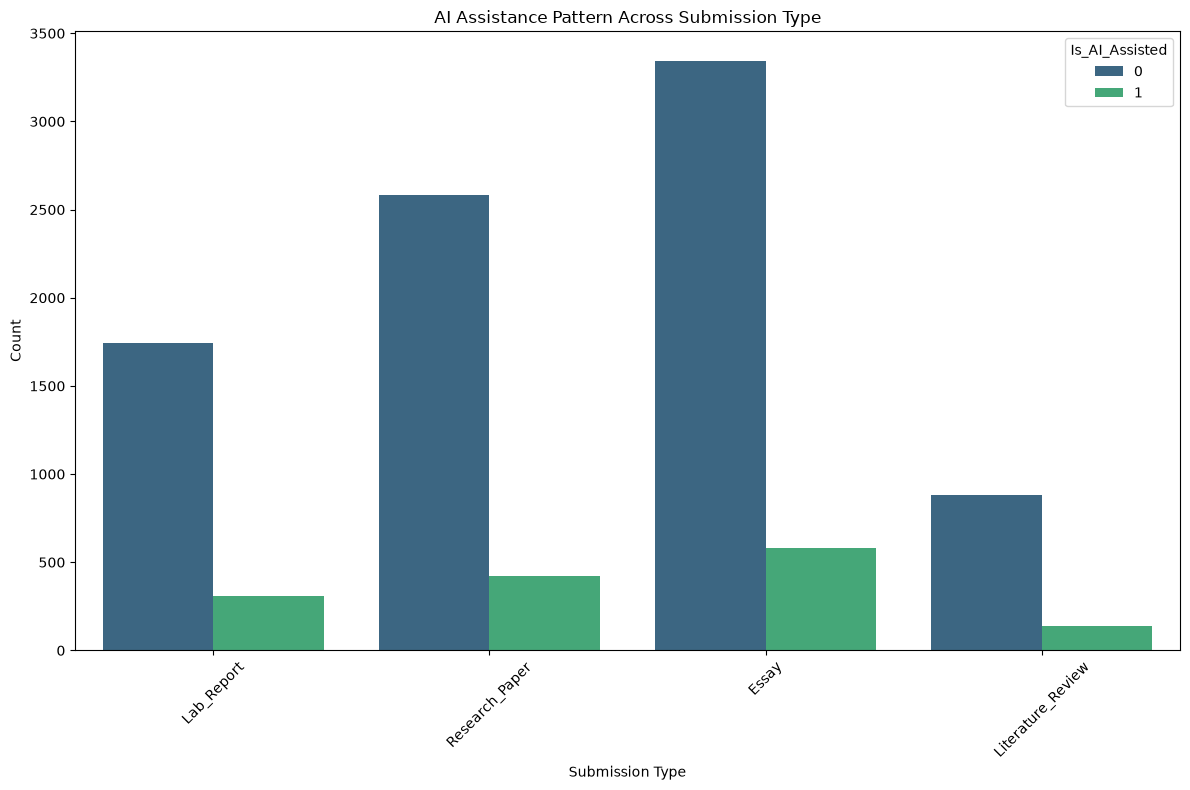

In [24]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='Submission_Type', hue='Is_AI_Assisted', palette='viridis')

plt.title('AI Assistance Pattern Across Submission Type')
plt.xticks(rotation=45)
plt.xlabel('Submission Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


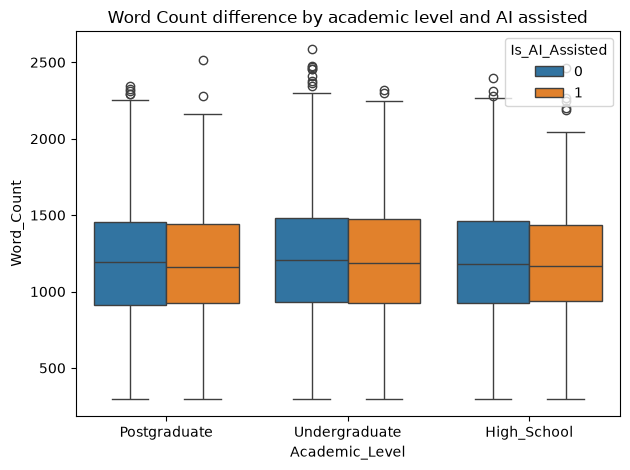

In [25]:
sns.boxplot(data =df , x = 'Academic_Level' , y = 'Word_Count' , hue = 'Is_AI_Assisted')
plt.title('Word Count difference by academic level and AI assisted')
plt.tight_layout()
plt.show()

<Axes: xlabel='Word_Count', ylabel='Count'>

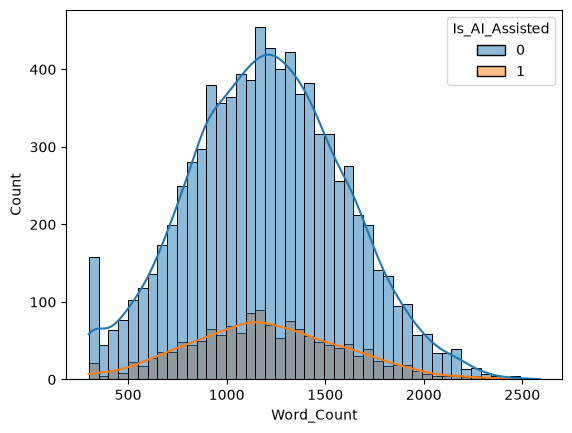

In [26]:
sns.histplot(data = df , x = 'Word_Count' , hue = 'Is_AI_Assisted', kde = True)

In [27]:
df.drop(columns = 'Student_ID',inplace = True)

In [28]:

df['Citation_Count'] = df['Citation_Count'].fillna(df['Citation_Count'].mean())


In [29]:
y = df['Is_AI_Assisted']
X = df.drop(columns = 'Is_AI_Assisted' , axis = 1)

ValueError: Cannot specify both 'axis' and 'index'/'columns'

In [ ]:
df['Academic_Level'].unique()

In [ ]:
y.value_counts()

In [ ]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

ordinal_cols = ['Academic_Level']
nomial_cols = [col for col in cat_cols if col != 'Academic_Level']

num_transformations = Pipeline(steps = [('imputer' , SimpleImputer(strategy='mean')),
                                        ('Scaling' , StandardScaler())])

ordinal_transformations = Pipeline(steps = [('imputer' , SimpleImputer(strategy='most_frequent')),
                                        ('Scaling' , OrdinalEncoder(categories = [['High_School' , 'Undergraduate' , 'Postgraduate']]))])

nomial_transformations = Pipeline(steps = [('imputer' , SimpleImputer(strategy='most_frequent')),
                                        ('Scaling' , OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num' , num_transformations , num_cols),
    ('ordinal' , ordinal_transformations , ordinal_cols),
    ('nominal' , nomial_transformations , nomial_cols)
],remainder = 'drop')

preprocessor

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 ,stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


models = {
    'Logistic Regression' : LogisticRegression(
        C = 0.5,                    # smaller c value = strong penality
        solver = 'lbfgs',            # Optimization algorithm
        max_iter=1000 ,             #no.of iterations
        class_weight= 'balanced'    #Adjust from imbalanced classes
        ),

    'Random Forest Classifier' : RandomForestClassifier(
        n_estimators=100,       # No.of trees
        max_depth=7,            # depth of tree
        min_samples_leaf= 2,     # minimum sample per leaf,
        min_samples_split = 4,   # minimum samples to split a node
        max_features='sqrt',     # Control randomness per split
        bootstrap=True,         # Sample with replacement
        random_state=42
    ),

    'Support Vector Machine' : SVC(
        C = 1.0,               # higher c value = less marigin and tighter fit
        kernel='linear',     # for linear data (kernel = rbf , ploy , linear , sigmoid)
        gamma = 'scale',       # low gamma = smoother boundary
        probability=True,       #  Uses sigmoid to output probabilities
        class_weight='balanced'
    ),

    'KNeighbors Classifiers' : KNeighborsClassifier(
        n_neighbors = 3,         # no.of neighbors 
        weights='distance',      # Uniform or Distance
        metric = 'minkowski',    # Distance metric
        p = 2                   # p=2 (Euclidean) , p=1 (Manhattan)
    ),

    'Decision Tree' : DecisionTreeClassifier(
        max_depth = 5,          # Max depth
        min_samples_split = 4,  # min samples to split a node
        min_samples_leaf = 2,   # min samples of a leaf
        criterion = 'gini',     # Gini for measures impurity(less = more accurate) or entropy
        splitter = 'best',      # best vs random split
        class_weight = 'balanced'
    )
}

In [ ]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

print(results)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Store all metrics together in a dictionary
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred)
    }

# Print results neatly
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    print("Accuracy:", metrics["accuracy"])
    print("Confusion Matrix:\n", metrics["confusion_matrix"])
    print("Classification Report:\n", metrics["classification_report"])
